# Chapter 13
## Linear models

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, OneHotEncoder, LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV, SGDRegressor
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV

## Linear regression

In [2]:
california = fetch_california_housing()
california

X = pd.DataFrame(scale(california.data), columns=california.feature_names)
y = california.target

display(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.2, random_state=42)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818
...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626


In [13]:
lm = LinearRegression()
lm.fit(X_train, y_train)

[print(feat+": "+str(round(coef, 2))) for feat, coef in zip(california.feature_names, lm.coef_)]
print(f"\ntrain R2:\t{lm.score(X_train, y_train):.3}")
print(f"test R2:\t{lm.score(X_test, y_test):.3}")

MedInc: 0.85
HouseAge: 0.12
AveRooms: -0.31
AveBedrms: 0.37
Population: -0.0
AveOccup: -0.04
Latitude: -0.9
Longitude: -0.87

train R2:	0.613
test R2:	0.576


### Visualize Multicollinearity with a Heatmap

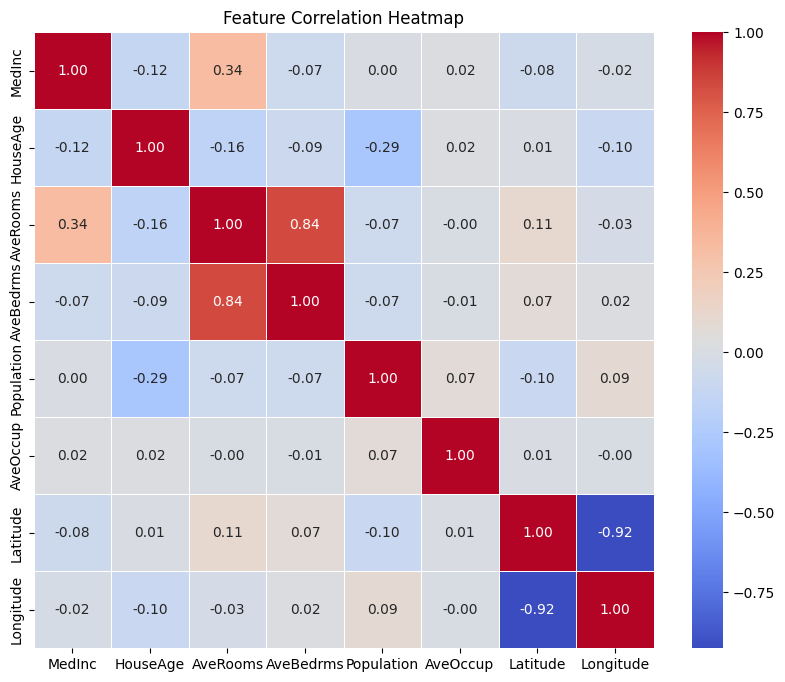

In [14]:
import seaborn as sns

# Calculate the correlation matrix for the training features
correlation_matrix = X_train.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### Calculate Variance Inflation Factor (VIF) to quantify multicollinearity

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Add a constant to the DataFrame to include the intercept in VIF calculation
X_train_const = sm.add_constant(X_train)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i)
                   for i in range(X_train_const.shape[1])]

# Display the VIF values, sorting by VIF in descending order
display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
7,Latitude,9.206134
8,Longitude,8.875984
3,AveRooms,7.917240
4,AveBedrms,6.609200
1,MedInc,2.539815
2,HouseAge,1.237337
5,Population,1.134824
6,AveOccup,1.009733
0,const,1.000079


### Remove high VIF features and retrain the model

In [37]:
# Identify features to remove based on high VIF
features_to_remove = ['Latitude', 'AveRooms']

# Actually neither GEO position in Lat/Lon is regressionable in real world,
# the meaningful data should be the distance to CBD, Coast, or OneHot which we will introduce soon above.
features_to_remove += ['Longitude',]

# Create new datasets with reduced features
X_train_reduced = X_train.drop(columns=features_to_remove)
X_test_reduced = X_test.drop(columns=features_to_remove)

# Retrain the Linear Regression model
lm_reduced = LinearRegression()
lm_reduced.fit(X_train_reduced, y_train)

# Display new coefficients
print("\nNew Model Coefficients (after removing high VIF features):")
[print(feat+": "+str(round(coef, 2))) for feat, coef in zip(X_train_reduced.columns, lm_reduced.coef_)]

# Display new R-squared scores
print(f"\nNew train R2:\t{lm_reduced.score(X_train_reduced, y_train):.3}")
print(f"New test R2:\t{lm_reduced.score(X_test_reduced, y_test):.3}")


New Model Coefficients (after removing high VIF features):
MedInc: 0.83
HouseAge: 0.24
AveBedrms: 0.03
Population: 0.04
AveOccup: -0.05

New train R2:	0.516
New test R2:	0.496


We have now retrained the model after removing `Latitude` and `AveRooms`. Observe the changes in the coefficients and R-squared scores. Often, removing highly correlated features can lead to more stable and interpretable coefficients, even if the overall R-squared doesn't change dramatically. The VIFs for the remaining features should also be lower, which we can check next if desired.

### Comparing Coefficients: Original vs. Reduced Model

**Original Model Coefficients:**


In [32]:
print("Feature: Original Coefficient")
[print(f"{feat}: {round(coef, 3)}") for feat, coef in zip(california.feature_names, lm.coef_)]

print("\n**Reduced Model Coefficients:**")
[print(f"{feat}: {round(coef, 3)}") for feat, coef in zip(X_train_reduced.columns, lm_reduced.coef_)]


Feature: Original Coefficient
MedInc: 0.852
HouseAge: 0.122
AveRooms: -0.305
AveBedrms: 0.371
Population: -0.002
AveOccup: -0.037
Latitude: -0.897
Longitude: -0.869

**Reduced Model Coefficients:**
MedInc: 0.828
HouseAge: 0.235
AveBedrms: 0.026
Population: 0.041
AveOccup: -0.045


[None, None, None, None, None]

By comparing these lists, you can observe how the coefficients of the remaining features have changed. This change reflects the reduction in multicollinearity, leading to potentially more stable and interpretable relationships between the features and the target variable.

### R-squared Value Comparison

| Model          | Train R-squared | Test R-squared |
|----------------|-----------------|----------------|
| Original Model | 0.613           | 0.576          |
| Reduced Model  | 0.516           | 0.496          |

As you can see, both the training and testing R-squared values decreased in the reduced model. This is an expected trade-off when removing features to address multicollinearity. While predictive power might slightly decrease, the model's interpretability and stability of coefficients generally improve.

In [7]:
# Manually calculate R-squared (R2), which measures the proportion of variance in the dependent variable that is predictable from the independent variables.
# R^2 = 1 - (Residual Sum of Squares) / (Total Sum of Squares)

In [33]:
mean_y_test = np.mean(y_test)
squared_error_test = np.sum((y_test - mean_y_test)**2)
residual_sum_of_squares_test = np.sum((y_test - lm.predict(X_test))**2)
r2_test = 1 - residual_sum_of_squares_test / squared_error_test

print(f"Test R2 (manual):\t{r2_test:.3}")

Test R2 (manual):	0.576


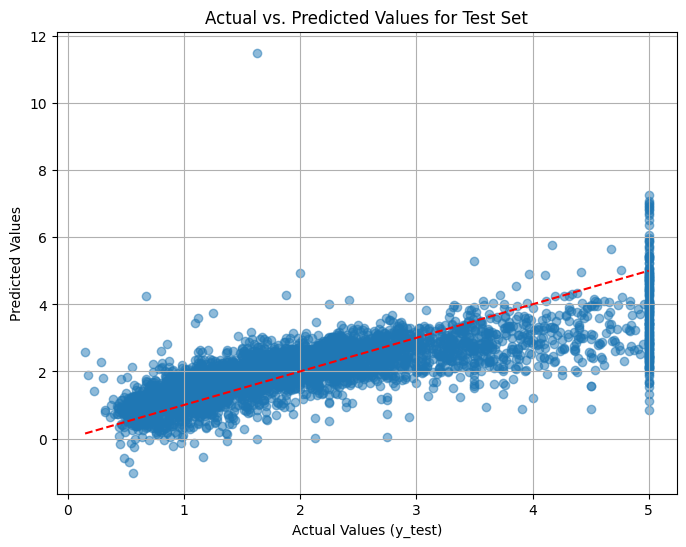

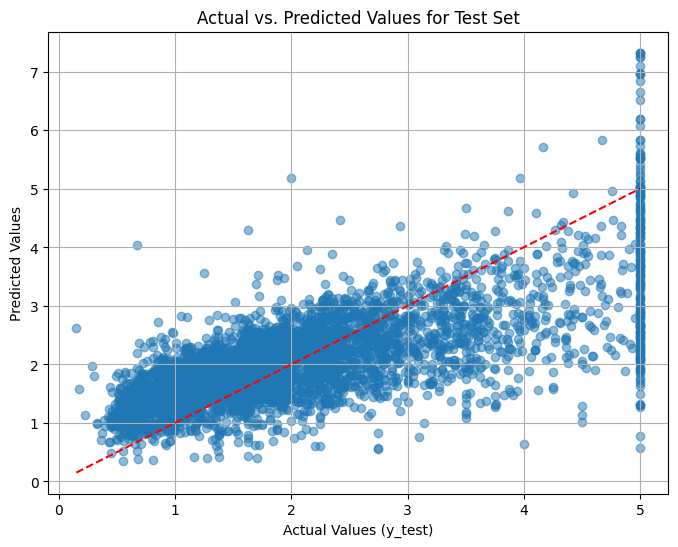

In [34]:
predictions = lm.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Test Set')
plt.grid(True)
plt.show()

predictions = lm_reduced.predict(X_test_reduced)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Test Set')
plt.grid(True)
plt.show()


### Cross-validation to check for overfitting

In [35]:
from sklearn.model_selection import cross_val_score

# Initialize the Linear Regression model
lm_cv = LinearRegression()

# Perform 5-fold cross-validation on the training data
cv_scores = cross_val_score(lm_cv, X_train, y_train, cv=5, scoring='r2')

print(f"Cross-validation R^2 scores: {cv_scores}")
print(f"Mean cross-validation R^2: {np.mean(cv_scores):.3f}")
print(f"Standard deviation of cross-validation R^2: {np.std(cv_scores):.3f}")

Cross-validation R^2 scores: [0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]
Mean cross-validation R^2: 0.611
Standard deviation of cross-validation R^2: 0.006


A high mean cross-validation R^2 score indicates that the model generalizes well across different subsets of the training data. A low standard deviation suggests that the model's performance is consistent. Comparing this to the training R^2 and test R^2 can help identify if the model is overfitting or underfitting.

### Qualitative features

In [38]:
lbl = LabelEncoder()
enc = OneHotEncoder(sparse_output=False)
qualitative = ['red', 'red', 'green', 'blue', 'red', 'blue', 'blue', 'green']

ordinal = lbl.fit_transform(qualitative).reshape(-1, 1)
one_hot = enc.fit_transform(np.asarray(qualitative).reshape(-1, 1))

for i, j, k in zip(qualitative, ordinal, one_hot):
    print(f"{i}\t{j}\t{k}")

red	[2]	[0. 0. 1.]
red	[2]	[0. 0. 1.]
green	[1]	[0. 1. 0.]
blue	[0]	[1. 0. 0.]
red	[2]	[0. 0. 1.]
blue	[0]	[1. 0. 0.]
blue	[0]	[1. 0. 0.]
green	[1]	[0. 1. 0.]


### Creating One-Hot Encoded Geographical Regions

To replace the direct `Latitude` and `Longitude` features, which contributed to multicollinearity, we can create new categorical features representing geographical regions. This involves:

1.  **Binning**: Discretizing the continuous `Latitude` and `Longitude` values into a few distinct categories.
2.  **Combining**: Creating a unique 'Geo_Region' label from the combined latitude and longitude bins.
3.  **One-Hot Encoding**: Converting these categorical 'Geo_Region' labels into numerical binary features.

These new features will then be added to our `_reduced` datasets, and the model will be retrained.

In [44]:
# Define the number of bins for Latitude and Longitude
num_lat_bins = 5
num_lon_bins = 5

# Bin Latitude and Longitude for training data
lat_bins_train = pd.cut(X_train['Latitude'], bins=num_lat_bins, labels=[f'Lat_B{i}' for i in range(num_lat_bins)], include_lowest=True)
lon_bins_train = pd.cut(X_train['Longitude'], bins=num_lon_bins, labels=[f'Lon_B{i}' for i in range(num_lon_bins)], include_lowest=True)
geo_regions_train = lat_bins_train.astype(str) + '_' + lon_bins_train.astype(str)

# Bin Latitude and Longitude for testing data using the same bin edges as training data
# We need to get the bin edges from the training data for consistent transformation
lat_bin_edges = pd.cut(X_train['Latitude'], bins=num_lat_bins, include_lowest=True, retbins=True)[1]
lon_bin_edges = pd.cut(X_train['Longitude'], bins=num_lon_bins, include_lowest=True, retbins=True)[1]

lat_bins_test = pd.cut(X_test['Latitude'], bins=lat_bin_edges, labels=[f'Lat_B{i}' for i in range(num_lat_bins)], include_lowest=True)
lon_bins_test = pd.cut(X_test['Longitude'], bins=lon_bin_edges, labels=[f'Lon_B{i}' for i in range(num_lon_bins)], include_lowest=True)
geo_regions_test = lat_bins_test.astype(str) + '_' + lon_bins_test.astype(str)

# Initialize OneHotEncoder, dropping the first category to avoid multicollinearity (dummy variable trap)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on training data and transform both training and testing geographical regions
geo_regions_ohe_train = ohe.fit_transform(geo_regions_train.to_frame())
geo_regions_ohe_test = ohe.transform(geo_regions_test.to_frame())

# Create DataFrames from the one-hot encoded arrays with appropriate column names and indices
geo_regions_ohe_df_train = pd.DataFrame(geo_regions_ohe_train, columns=ohe.get_feature_names_out(['Geo_Region']), index=X_train_reduced.index)
geo_regions_ohe_df_test = pd.DataFrame(geo_regions_ohe_test, columns=ohe.get_feature_names_out(['Geo_Region']), index=X_test_reduced.index)

# Concatenate with the previously reduced datasets
X_train_geo_ohe = pd.concat([X_train_reduced, geo_regions_ohe_df_train], axis=1)
X_test_geo_ohe = pd.concat([X_test_reduced, geo_regions_ohe_df_test], axis=1)

# Retrain the Linear Regression model
lm_geo_ohe = LinearRegression()
lm_geo_ohe.fit(X_train_geo_ohe, y_train)

# Display new coefficients
print("\nNew Model Coefficients (after adding one-hot encoded geographic features):")
[print(feat+": "+str(round(coef, 2))) for feat, coef in zip(X_train_geo_ohe.columns, lm_geo_ohe.coef_)]

# Display new R-squared scores
print(f"\nNew train R2:\t{lm_geo_ohe.score(X_train_geo_ohe, y_train):.3}")
print(f"New test R2:\t{lm_geo_ohe.score(X_test_geo_ohe, y_test):.3}")


New Model Coefficients (after adding one-hot encoded geographic features):
MedInc: 0.72
HouseAge: 0.11
AveBedrms: 0.05
Population: -0.01
AveOccup: -0.03
Geo_Region_Lat_B0_Lon_B3: -0.68
Geo_Region_Lat_B0_Lon_B4: -1.39
Geo_Region_Lat_B1_Lon_B1: -0.62
Geo_Region_Lat_B1_Lon_B2: -1.09
Geo_Region_Lat_B1_Lon_B3: -1.32
Geo_Region_Lat_B1_Lon_B4: -1.5
Geo_Region_Lat_B2_Lon_B0: 0.27
Geo_Region_Lat_B2_Lon_B1: -0.62
Geo_Region_Lat_B2_Lon_B2: -1.44
Geo_Region_Lat_B2_Lon_B3: -1.53
Geo_Region_Lat_B3_Lon_B0: -0.74
Geo_Region_Lat_B3_Lon_B1: -1.15
Geo_Region_Lat_B3_Lon_B2: -1.24
Geo_Region_Lat_B4_Lon_B0: -1.32
Geo_Region_Lat_B4_Lon_B1: -1.41
Geo_Region_Lat_B4_Lon_B2: -1.79

New train R2:	0.618
New test R2:	0.596


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


We have now introduced one-hot encoded geographical features. Observe how the R-squared values and coefficients have changed with this new representation. This approach can sometimes capture non-linear relationships in geographical influence better than direct numerical coordinates, while also mitigating multicollinearity.

### Calculate VIF for the Model with One-Hot Encoded Geographic Features

In [46]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant to the DataFrame to include the intercept in VIF calculation
X_train_geo_ohe_const = sm.add_constant(X_train_geo_ohe)

# Calculate VIF for each feature
vif_data_geo_ohe = pd.DataFrame()
vif_data_geo_ohe["feature"] = X_train_geo_ohe_const.columns
vif_data_geo_ohe["VIF"] = [variance_inflation_factor(X_train_geo_ohe_const.values, i)
                           for i in range(X_train_geo_ohe_const.shape[1])]

# Display the VIF values, sorting by VIF in descending order
display(vif_data_geo_ohe.sort_values(by='VIF', ascending=False))

,feature,VIF
0,const,9.051385
6,Geo_Region_Lat_B0_Lon_B3,2.767737
13,Geo_Region_Lat_B2_Lon_B1,2.240991
17,Geo_Region_Lat_B3_Lon_B1,1.636457
12,Geo_Region_Lat_B2_Lon_B0,1.371150
14,Geo_Region_Lat_B2_Lon_B2,1.356764
2,HouseAge,1.290083
9,Geo_Region_Lat_B1_Lon_B2,1.281802
16,Geo_Region_Lat_B3_Lon_B0,1.227783
18,Geo_Region_Lat_B3_Lon_B2,1.209996


Review the VIF values for this model. Ideally, all VIFs should be below 5 or 10, indicating that multicollinearity is no longer a significant issue. This step confirms the effectiveness of replacing `Latitude` and `Longitude` with one-hot encoded regions.

### Comparison of Model Coefficients

In [48]:
# Display coefficients for the Geographic OHE model
print("Geographic OHE Model Coefficients:")
[print(feat+": "+str(round(coef, 2))) for feat, coef in zip(X_train_geo_ohe.columns, lm_geo_ohe.coef_)]


Geographic OHE Model Coefficients:
MedInc: 0.72
HouseAge: 0.11
AveBedrms: 0.05
Population: -0.01
AveOccup: -0.03
Geo_Region_Lat_B0_Lon_B3: -0.68
Geo_Region_Lat_B0_Lon_B4: -1.39
Geo_Region_Lat_B1_Lon_B1: -0.62
Geo_Region_Lat_B1_Lon_B2: -1.09
Geo_Region_Lat_B1_Lon_B3: -1.32
Geo_Region_Lat_B1_Lon_B4: -1.5
Geo_Region_Lat_B2_Lon_B0: 0.27
Geo_Region_Lat_B2_Lon_B1: -0.62
Geo_Region_Lat_B2_Lon_B2: -1.44
Geo_Region_Lat_B2_Lon_B3: -1.53
Geo_Region_Lat_B3_Lon_B0: -0.74
Geo_Region_Lat_B3_Lon_B1: -1.15
Geo_Region_Lat_B3_Lon_B2: -1.24
Geo_Region_Lat_B4_Lon_B0: -1.32
Geo_Region_Lat_B4_Lon_B1: -1.41
Geo_Region_Lat_B4_Lon_B2: -1.79


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [49]:
# Coefficients for the Polynomial Features model
# First, ensure the model is trained with the polynomial features
pf_compare = PolynomialFeatures(degree=2)
poly_X_train_compare, poly_X_test_compare = pf_compare.fit_transform(X_train), pf_compare.fit_transform(X_test)

lm_poly_compare = LinearRegression()
lm_poly_compare.fit(poly_X_train_compare, y_train)

print("\nPolynomial Features Model Coefficients:")
# The number of coefficients can be large, so we'll display a subset or summarize
# For simplicity, let's just print the first few for demonstration.
# A full print can be very long depending on the number of polynomial features.
# The feature names are more complex for polynomial features.
poly_feature_names = pf_compare.get_feature_names_out(X_train.columns)
for i, (feat, coef) in enumerate(zip(poly_feature_names, lm_poly_compare.coef_)):
    if i < 20: # Displaying first 20 coefficients to avoid excessive output
        print(f"{feat}: {round(coef, 2)}")
    else:
        print("...")
        break



Polynomial Features Model Coefficients:
1: 0.0
MedInc: 0.93
HouseAge: 0.13
AveRooms: -0.4
AveBedrms: 0.58
Population: 0.04
AveOccup: -1.6
Latitude: -1.27
Longitude: -1.17
MedInc^2: -0.11
MedInc HouseAge: 0.04
MedInc AveRooms: 0.19
MedInc AveBedrms: -0.13
MedInc Population: 0.11
MedInc AveOccup: -0.09
MedInc Latitude: -0.67
MedInc Longitude: -0.58
HouseAge^2: 0.03
HouseAge AveRooms: -0.02
HouseAge AveBedrms: 0.06
...


### Residual Analysis for Polynomial Features Model

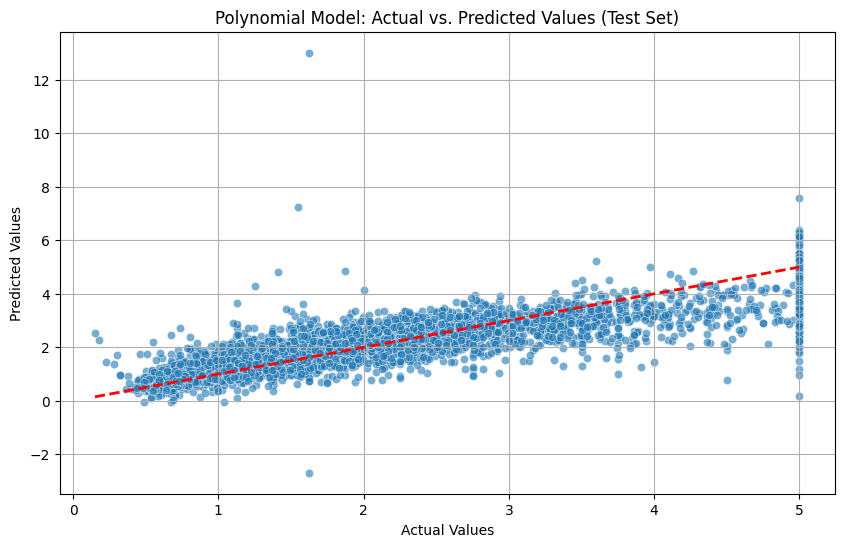

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions for the Polynomial Features model on the test set
poly_predictions = lm_poly_compare.predict(poly_X_test_compare)

# Create a scatter plot of Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=poly_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Polynomial Model: Actual vs. Predicted Values (Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

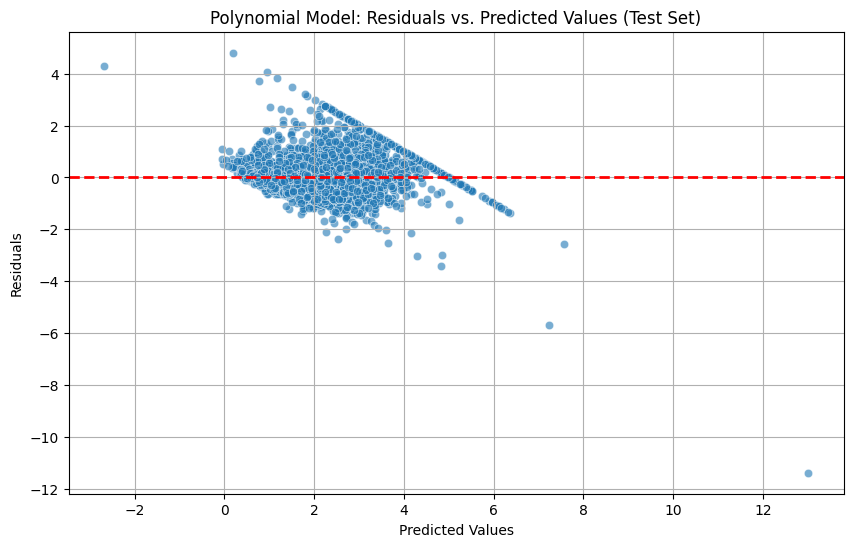

In [51]:
# Calculate residuals
poly_residuals = y_test - poly_predictions

# Create a scatter plot of Residuals vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=poly_predictions, y=poly_residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.title('Polynomial Model: Residuals vs. Predicted Values (Test Set)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Polynomial Features

In [52]:
pf = PolynomialFeatures(degree=2)
poly_X_train, poly_X_test = pf.fit_transform(X_train), pf.fit_transform(X_test)

lm = LinearRegression()
lm.fit(poly_X_train, y_train)

print(f"train R2:\t{lm.score(poly_X_train, y_train):.3}")
print(f"test R2:\t{lm.score(poly_X_test, y_test):.3}")

train R2:	0.685
test R2:	0.646


### Addressing Heteroscedasticity with Weighted Least Squares (WLS)

To mitigate heteroscedasticity, we will employ Weighted Least Squares (WLS). The core idea of WLS is to assign different weights to each observation in the regression, giving less influence to observations that have higher variance in their errors. This helps to stabilize the variance of the residuals.

We will estimate the weights by using the inverse of the squared residuals from our previously trained OLS polynomial model. This means observations with larger absolute residuals (which indicate higher variance) will receive smaller weights, and vice-versa. We will add a small constant to the denominator to prevent division by zero or extremely large weights.

In [53]:
import statsmodels.api as sm

# Add a constant to the polynomial features for statsmodels (if not already present)
poly_X_train_const_sm = sm.add_constant(poly_X_train_compare, prepend=False)
poly_X_test_const_sm = sm.add_constant(poly_X_test_compare, prepend=False)

# --- Step 1: Obtain residuals from the OLS polynomial model ---
# We need the predictions from the original OLS polynomial model on the training data
poly_predictions_train = lm_poly_compare.predict(poly_X_train_compare)
poly_residuals_train = y_train - poly_predictions_train

# --- Step 2: Estimate weights ---
# Weights are typically inversely proportional to the variance of the error term.
# A common heuristic is 1 / (squared residuals).
# Add a small epsilon to avoid division by zero or very large weights for near-zero residuals.
weights = 1 / (poly_residuals_train**2 + 1e-6)

print("Weights calculated based on inverse squared residuals from OLS polynomial model.")
# Display some info about weights to confirm
print(f"Min weight: {weights.min():.3f}, Max weight: {weights.max():.3f}, Mean weight: {weights.mean():.3f}")

Weights calculated based on inverse squared residuals from OLS polynomial model.
Min weight: 0.016, Max weight: 999691.054, Mean weight: 2098.266


In [54]:
# --- Step 3: Train the WLS model ---
wls_model = sm.WLS(y_train, poly_X_train_const_sm, weights=weights)
wls_results = wls_model.fit()

print("\n--- WLS Model Summary ---")
print(wls_results.summary())

# Evaluate R-squared for WLS model
wls_train_r2 = wls_results.rsquared
wls_predictions_test = wls_results.predict(poly_X_test_const_sm)
# To calculate test R2, we need to manually compute it since WLS.predict doesn't directly give score.
# The R-squared from statsmodels summary is for the weighted data, which is not directly comparable to OLS R-squared on original scale.
# For comparison with OLS R2, it's better to calculate R2 on the *original* scale using standard sklearn metrics.
from sklearn.metrics import r2_score
wls_test_r2 = r2_score(y_test, wls_predictions_test)

print(f"\nTrain R2 (WLS):\t{wls_train_r2:.3}")
print(f"Test R2 (WLS on original scale):\t{wls_test_r2:.3}")


--- WLS Model Summary ---
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            WLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.247e+05
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:05:43   Log-Likelihood:                -2258.4
No. Observations:               16512   AIC:                             4607.
Df Residuals:                   16467   BIC:                             4954.
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9549    

### Residual Analysis for Weighted Least Squares (WLS) Model

Now, let's plot the residuals of the WLS model to see if the heteroscedasticity has been reduced. We expect to see a more uniform spread of residuals around zero across the range of predicted values.

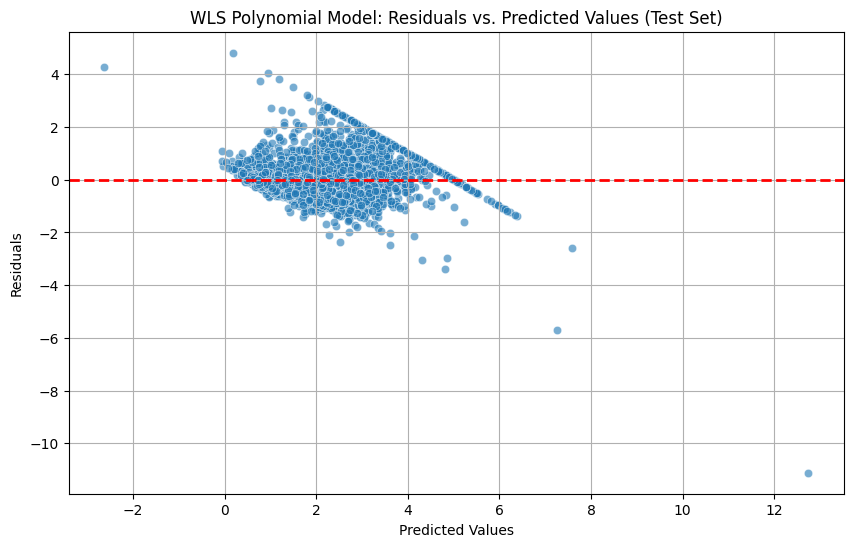

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the WLS model on the test set
wls_residuals = y_test - wls_predictions_test

# Create a scatter plot of WLS Residuals vs. WLS Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=wls_predictions_test, y=wls_residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.title('WLS Polynomial Model: Residuals vs. Predicted Values (Test Set)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

### Addressing Heteroscedasticity with Log Transformation on Target Variable

Given that the Weighted Least Squares approach did not fully resolve the heteroscedasticity, we will now try transforming the target variable `y` using a natural logarithm. This transformation can often stabilize the variance of the errors, making the residuals more uniformly spread across the range of predicted values. We will use `np.log1p` which computes `log(1+x)` to handle cases where `y` might contain zero values.

In [56]:
import numpy as np

# Apply log1p transformation to the target variables
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Target variable (y) transformed using np.log1p.")

# Retrain the polynomial model with the log-transformed target variable
# We'll reuse the poly_X_train and poly_X_test generated earlier

lm_poly_log = LinearRegression()
lm_poly_log.fit(poly_X_train, y_train_log)

# Evaluate the R-squared on the log-transformed scale
train_r2_log = lm_poly_log.score(poly_X_train, y_train_log)
test_r2_log = lm_poly_log.score(poly_X_test, y_test_log)

print(f"\nTrain R2 (Polynomial + Log Y):\t{train_r2_log:.3}")
print(f"Test R2 (Polynomial + Log Y):\t{test_r2_log:.3}")

# To make predictions comparable to the original scale, we need to inverse transform them
# The inverse of log1p is np.expm1 (e^x - 1)
predictions_test_log = lm_poly_log.predict(poly_X_test)
predictions_test_original_scale = np.expm1(predictions_test_log)

# Calculate R-squared on the original scale for better comparison
from sklearn.metrics import r2_score
original_scale_test_r2 = r2_score(y_test, predictions_test_original_scale)

print(f"Test R2 (Polynomial + Log Y, original scale):\t{original_scale_test_r2:.3}")

Target variable (y) transformed using np.log1p.

Train R2 (Polynomial + Log Y):	0.71
Test R2 (Polynomial + Log Y):	0.698
Test R2 (Polynomial + Log Y, original scale):	0.654


### Residual Analysis for Log-Transformed Polynomial Model

Now, let's examine the residuals for the polynomial model trained on the log-transformed target variable. We will plot both actual vs. predicted and residuals vs. predicted values to assess if the heteroscedasticity has been addressed.

### Log-Transformed Polynomial Model: Regression Expression

Below is the regression expression for our best performing model, the Log-Transformed Polynomial Model. Note that `np.log1p(y_hat)` is the predicted value on the log scale, and `np.expm1(np.log1p(y_hat))` would transform it back to the original scale. Due to the high number of polynomial features, only the intercept and the first few terms are displayed.

In [58]:
import numpy as np

# Ensure pf and lm_poly_log are the correct objects from the log-transformed model
# In our case, lm_poly_log was trained on poly_X_train derived from pf

# Get the feature names generated by PolynomialFeatures
poly_feature_names = pf.get_feature_names_out(X_train.columns)

# Get the coefficients from the trained LinearRegression model
coefficients = lm_poly_log.coef_
intercept = lm_poly_log.intercept_

# Build the regression expression string
expression = f"np.log1p(y_hat) = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    if i < len(poly_feature_names):
        # Exclude the '1' term if it's the first feature as it's already handled by intercept
        if poly_feature_names[i] == '1':
            continue
        expression += f" + ({coef:.4f} * {poly_feature_names[i]})"

# Print the full expression
print(expression)

# Optionally, print the inverse transformed expression
print(f"\nOr, on the original scale: y_hat = np.expm1({intercept:.4f}")
for i, coef in enumerate(coefficients):
    if i < len(poly_feature_names):
        if poly_feature_names[i] == '1':
            continue
        expression += f" + ({coef:.4f} * {poly_feature_names[i]})"
print(f" + ({coef:.4f} * {poly_feature_names[i]}) for i in polynomial features...))")

np.log1p(y_hat) = 1.0316 + (0.3033 * MedInc) + (0.0337 * HouseAge) + (-0.1267 * AveRooms) + (0.1674 * AveBedrms) + (0.0159 * Population) + (-0.4829 * AveOccup) + (-0.4334 * Latitude) + (-0.3955 * Longitude) + (-0.0431 * MedInc^2) + (0.0108 * MedInc HouseAge) + (0.0530 * MedInc AveRooms) + (-0.0434 * MedInc AveBedrms) + (0.0330 * MedInc Population) + (-0.0094 * MedInc AveOccup) + (-0.1209 * MedInc Latitude) + (-0.1060 * MedInc Longitude) + (0.0092 * HouseAge^2) + (-0.0103 * HouseAge AveRooms) + (0.0180 * HouseAge AveBedrms) + (0.0095 * HouseAge Population) + (-0.0665 * HouseAge AveOccup) + (-0.0876 * HouseAge Latitude) + (-0.0787 * HouseAge Longitude) + (0.0196 * AveRooms^2) + (-0.0369 * AveRooms AveBedrms) + (-0.0551 * AveRooms Population) + (0.1796 * AveRooms AveOccup) + (0.1629 * AveRooms Latitude) + (0.1452 * AveRooms Longitude) + (0.0170 * AveBedrms^2) + (0.0862 * AveBedrms Population) + (-0.1106 * AveBedrms AveOccup) + (-0.1395 * AveBedrms Latitude) + (-0.1198 * AveBedrms Longitud

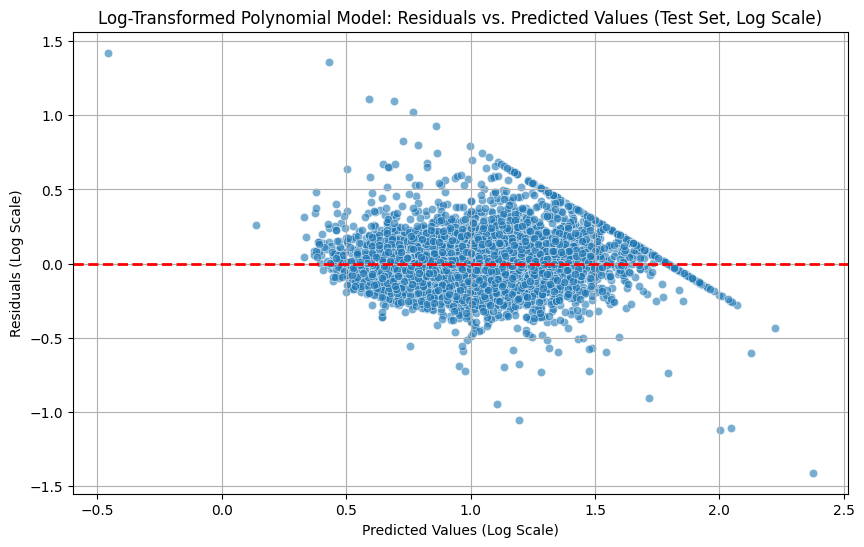

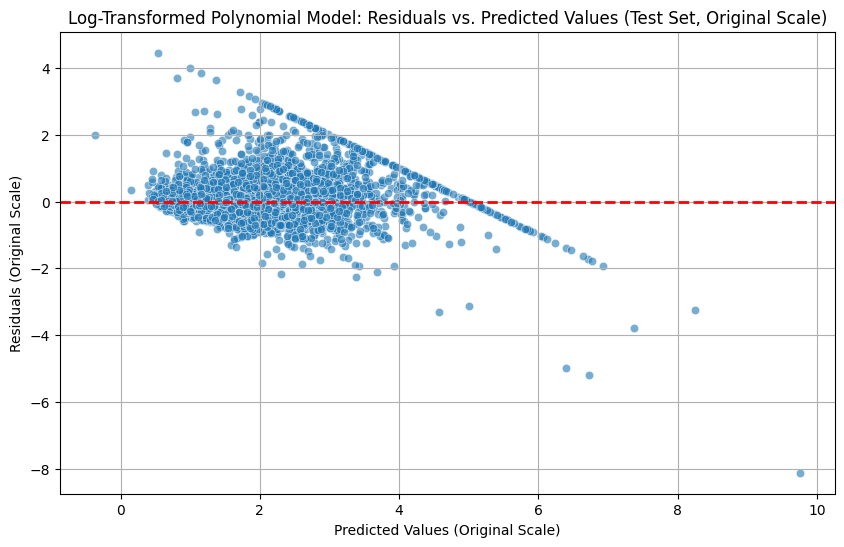

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals on the log-transformed scale for visual inspection of homoscedasticity
residuals_log = y_test_log - predictions_test_log

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions_test_log, y=residuals_log, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Log-Transformed Polynomial Model: Residuals vs. Predicted Values (Test Set, Log Scale)')
plt.xlabel('Predicted Values (Log Scale)')
plt.ylabel('Residuals (Log Scale)')
plt.grid(True)
plt.show()

# Also plot residuals on the original scale to see overall fit
residuals_original_scale = y_test - predictions_test_original_scale

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predictions_test_original_scale, y=residuals_original_scale, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Log-Transformed Polynomial Model: Residuals vs. Predicted Values (Test Set, Original Scale)')
plt.xlabel('Predicted Values (Original Scale)')
plt.ylabel('Residuals (Original Scale)')
plt.grid(True)
plt.show()


## Classification
Regression cannot solve classification

In [69]:
y = np.concatenate([np.zeros(4), np.ones(4)])
X = np.arange(1, 9).reshape(-1, 1)

lm = LinearRegression()
lm.fit(X, y)
preds = lm.predict(X)

for y_true, y_pred in zip(y, preds):
    print(f"{y_true} -> {y_pred:+.3}")

0.0 -> -0.167
0.0 -> +0.0238
0.0 -> +0.214
0.0 -> +0.405
1.0 -> +0.595
1.0 -> +0.786
1.0 -> +0.976
1.0 -> +1.17


In [84]:
lr = LogisticRegression()
lr.fit(X_train, y_train >= 3.772)

in_sample_acc = accuracy_score(y_train >= 3.772, lr.predict(X_train))
out_sample_acc = accuracy_score(y_test >= 3.772, lr.predict(X_test))

print(f"In-sample accuracy: {in_sample_acc:.3}")
print(f"Out-sample accuracy: {out_sample_acc:.3}\n")
for var, coef in zip(X_train.columns, lr.coef_[0]):
    print(f"{var}: \t{coef:+.3}")

print('\nClasses:', lr.classes_)
# Access the probability of the positive class (index 1) for each prediction
print('Probabilities:\n', ['%.3f %.3f' % (x[0], x[1]) for x in lr.predict_proba(X_test)[:5]])

In-sample accuracy: 0.938
Out-sample accuracy: 0.937

MedInc: 	+2.22
HouseAge: 	+0.677
AveRooms: 	-0.788
AveBedrms: 	+1.04
Population: 	+0.0639
AveOccup: 	-10.3
Latitude: 	-3.54
Longitude: 	-3.04

Classes: [False  True]
Probabilities:
 ['1.000 0.000', '0.987 0.013', '0.584 0.416', '0.924 0.076', '0.858 0.142']


In [85]:
from sklearn.metrics import confusion_matrix

# Get predictions from the logistic regression model on the test set
predictions_binary = lr.predict(X_test)

# Get the true binary labels for the test set
true_binary_labels = (y_test >= 3.772)

# Calculate the confusion matrix
cm = confusion_matrix(true_binary_labels, predictions_binary)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[3683   42]
 [ 218  185]]


## Feature selection

In [86]:
r2_train = []
r2_test = []

for i in range(1, 129):
    X_train_extra = np.column_stack((X_train, np.random.rand(len(X_train), i)))
    X_test_extra = np.column_stack((X_test, np.random.rand(len(X_test), i)))

    lr = LinearRegression()
    lr.fit(X_train_extra, y_train)
    r2_train.append(lr.score(X_train_extra, y_train))
    r2_test.append(lr.score(X_test_extra, y_test))

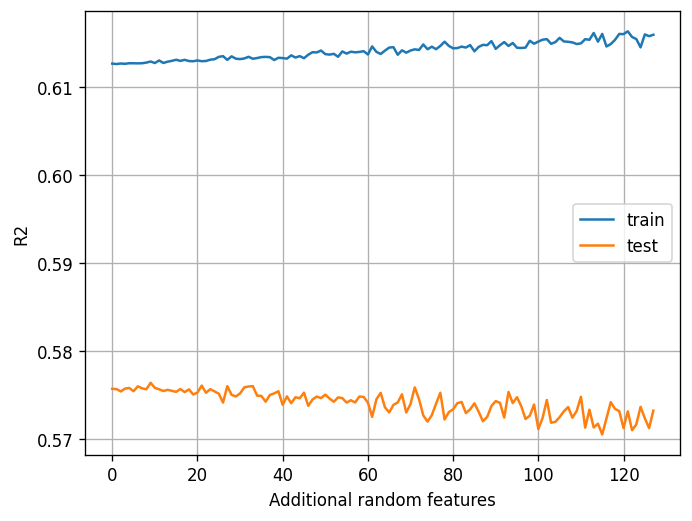

In [87]:
fig, ax = plt.subplots(dpi=120)
plt.plot(r2_train, label='train')
plt.plot(r2_test, label='test')
plt.xlabel("Additional random features")
plt.ylabel("R2")
plt.legend()
plt.grid()
plt.show()

In [88]:
pf = PolynomialFeatures(degree=2)
poly_X_train = pf.fit_transform(X_train)
poly_X_test = pf.fit_transform(X_test)

selector = RFECV(estimator=LinearRegression(), step=1, cv=10, scoring='r2')

selector.fit(poly_X_train, y_train)

n_features = selector.n_features_
print(f"Features reduced to {n_features} from {poly_X_train.shape[1]}")

r2_train = selector.score(poly_X_train, y_train)
r2_test = selector.score(poly_X_test, y_test)
print(f"\nR2 train:\t{r2_train:.3}")
print(f"R2 test:\t{r2_test:.3}")

Features reduced to 4 from 45

R2 train:	0.588
R2 test:	0.572


In [89]:
warnings.filterwarnings('ignore')

# Initialize StandardScaler and scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize RidgeCV without the normalize parameter
l2_lm = RidgeCV(alphas=np.logspace(-3, 2, num=6), cv=5, scoring='r2')
l2_lm.fit(X_train_scaled, y_train)

best_alpha = l2_lm.alpha_
r2_test = l2_lm.score(X_test_scaled, y_test)

print(f"Best alpha:\t{best_alpha}")
print(f"Test R2:\t{r2_test:.3}\n")
for var, coef in zip(X_train.columns, l2_lm.coef_):
    print(f"{var}: \t{coef:+.3}")

Best alpha:	0.001
Test R2:	0.576

MedInc: 	+0.854
HouseAge: 	+0.123
AveRooms: 	-0.294
AveBedrms: 	+0.339
Population: 	-0.00231
AveOccup: 	-0.0408
Latitude: 	-0.897
Longitude: 	-0.87


In [90]:
warnings.filterwarnings('ignore')

# Initialize StandardScaler and scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize LassoCV without the normalize parameter
l1_lm = LassoCV(alphas=np.logspace(-3, 2, num=6), cv=5)
l1_lm.fit(X_train_scaled, y_train)

best_alpha = l1_lm.alpha_
r2_test = l1_lm.score(X_test_scaled, y_test)

print(f"Best alpha:\t{best_alpha}")
print(f"Test R2:\t{r2_test:.3}\n")
for var, coef in zip(X_train.columns, l1_lm.coef_):
    print(f"{var}: \t{coef:+.3}")

Best alpha:	0.001
Test R2:	0.577

MedInc: 	+0.849
HouseAge: 	+0.123
AveRooms: 	-0.281
AveBedrms: 	+0.326
Population: 	-0.00106
AveOccup: 	-0.0399
Latitude: 	-0.886
Longitude: 	-0.858


## Stochastic gradient descent

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10


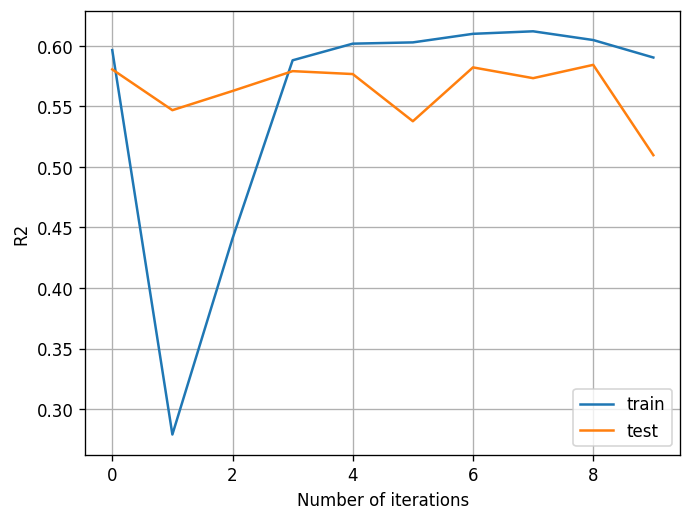

In [97]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler and fit it on the entire training data once
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale the target variable y as well
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# Initialize SGDRegressor directly, as data is already scaled
sgd_regressor = SGDRegressor(
    penalty="l2",
    learning_rate="invscaling",
    eta0=0.01,
    power_t=0.25,
    random_state=42,
    warm_start=True # Important for partial_fit to continue training
)

r2_train = []
r2_test = []

for i in range(10):
    print("Epoch:", i+1)
    # Shuffle X_train_scaled and y_train_scaled for each epoch to ensure randomness
    indices = np.arange(len(X_train_scaled))
    np.random.shuffle(indices)

    for j in indices:
        # partial_fit the SGDRegressor on the pre-scaled NumPy data
        # Use y_train_scaled[j] which is already a 1-element array after reshaping/scaling
        sgd_regressor.partial_fit(X_train_scaled[[j],:], y_train_scaled[j])

    r2_train.append(sgd_regressor.score(X_train_scaled, y_train_scaled))
    r2_test.append(sgd_regressor.score(X_test_scaled, y_test_scaled))

fig, ax = plt.subplots(dpi=120)
plt.plot(r2_train, label='train')
plt.plot(r2_test, label='test')
plt.xlabel("Number of iterations")
plt.ylabel("R2")
plt.legend()
plt.grid()
plt.show()

In [98]:
r2_sgd_df = pd.DataFrame({
    'Model': ['SGDRegressor'],
    'Train R2': [r2_train[-1]],
    'Test R2': [r2_test[-1]]
})

df_r2 = pd.concat([df_r2, r2_sgd_df], ignore_index=True)
display(df_r2)

,Model,Train R2,Test R2
0,Geographic OHE,0.618000,0.596000
1,Polynomial Features,0.685000,0.646000
2,SGDRegressor,0.590362,0.509725


In [99]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'loss': ['squared_error', 'huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['invscaling', 'adaptive'],
    'eta0': [0.01, 0.1, 0.5],
    'power_t': [0.25, 0.5],
    'max_iter': [1000] # Set a fixed max_iter for GridSearchCV
}

# Initialize SGDRegressor (without warm_start for GridSearchCV)
sgd_regressor_tuned = SGDRegressor(
    random_state=42
)

# Perform GridSearchCV
# We use the scaled X and y data that was previously prepared.
# Note: GridSearchCV will fit the model fully on each fold, not incrementally with partial_fit.
grid_search = GridSearchCV(
    sgd_regressor_tuned,
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train_scaled.ravel()) # .ravel() to convert y_train_scaled back to 1D array

print("Best hyperparameters found:")
print(grid_search.best_params_)

# Get the best model
best_sgd_regressor = grid_search.best_estimator_

# Evaluate the best model
train_r2_tuned = best_sgd_regressor.score(X_train_scaled, y_train_scaled)
test_r2_tuned = best_sgd_regressor.score(X_test_scaled, y_test_scaled)

print(f"\nBest SGDRegressor Train R2: {train_r2_tuned:.3f}")
print(f"Best SGDRegressor Test R2: {test_r2_tuned:.3f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best hyperparameters found:
{'alpha': 0.0001, 'eta0': 0.1, 'learning_rate': 'adaptive', 'loss': 'squared_error', 'max_iter': 1000, 'penalty': 'l2', 'power_t': 0.25}

Best SGDRegressor Train R2: 0.612
Best SGDRegressor Test R2: 0.572


In [101]:
# Add the tuned SGDRegressor results to df_r2
r2_sgd_tuned_df = pd.DataFrame({
    'Model': ['SGDRegressor (Tuned)'],
    'Train R2': [train_r2_tuned],
    'Test R2': [test_r2_tuned]
})

df_r2 = pd.concat([df_r2, r2_sgd_tuned_df], ignore_index=True)
display(df_r2)

,Model,Train R2,Test R2
0,Geographic OHE,0.618000,0.596000
1,Polynomial Features,0.685000,0.646000
2,SGDRegressor,0.590362,0.509725
3,SGDRegressor (Tuned),0.611858,0.572093
4,SGDRegressor (Tuned),0.611858,0.572093


In [102]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# Scale the polynomial features
scaler_poly = StandardScaler()
poly_X_train_scaled = scaler_poly.fit_transform(poly_X_train)
poly_X_test_scaled = scaler_poly.transform(poly_X_test)

# Initialize RidgeCV with a range of alpha values
ridge_poly_lm = RidgeCV(
    alphas=np.logspace(-3, 2, num=100), # Test 100 alpha values from 0.001 to 100
    cv=5, # 5-fold cross-validation
    scoring='r2' # Evaluate based on R-squared
)

# Fit the model
ridge_poly_lm.fit(poly_X_train_scaled, y_train)

# Get the best alpha
best_alpha_ridge_poly = ridge_poly_lm.alpha_

# Evaluate the model
train_r2_ridge_poly = ridge_poly_lm.score(poly_X_train_scaled, y_train)
test_r2_ridge_poly = ridge_poly_lm.score(poly_X_test_scaled, y_test)

print(f"Best alpha for Ridge with Polynomial Features: {best_alpha_ridge_poly:.4f}")
print(f"Ridge Polynomial Features Train R2: {train_r2_ridge_poly:.3f}")
print(f"Ridge Polynomial Features Test R2: {test_r2_ridge_poly:.3f}")

Best alpha for Ridge with Polynomial Features: 100.0000
Ridge Polynomial Features Train R2: 0.673
Ridge Polynomial Features Test R2: 0.657


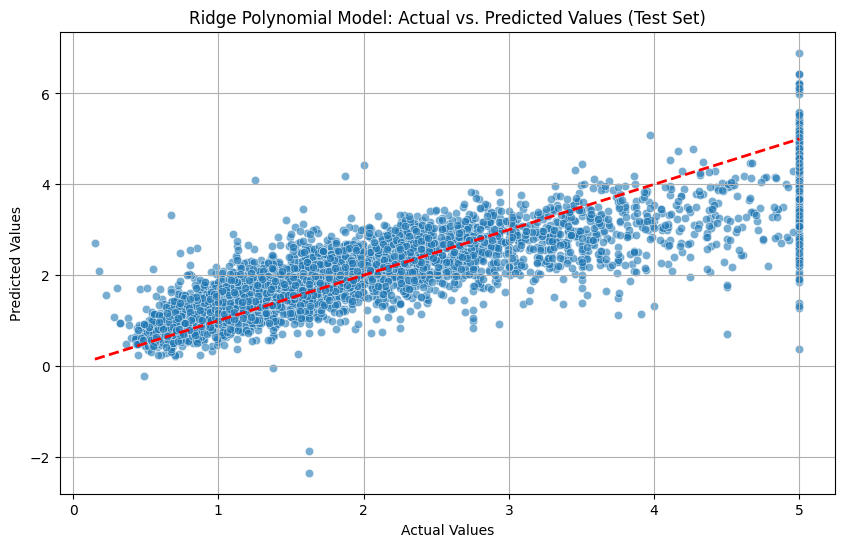

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions for the Ridge Polynomial model on the scaled test set
ridge_poly_predictions = ridge_poly_lm.predict(poly_X_test_scaled)

# Create a scatter plot of Actual vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=ridge_poly_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Ridge Polynomial Model: Actual vs. Predicted Values (Test Set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

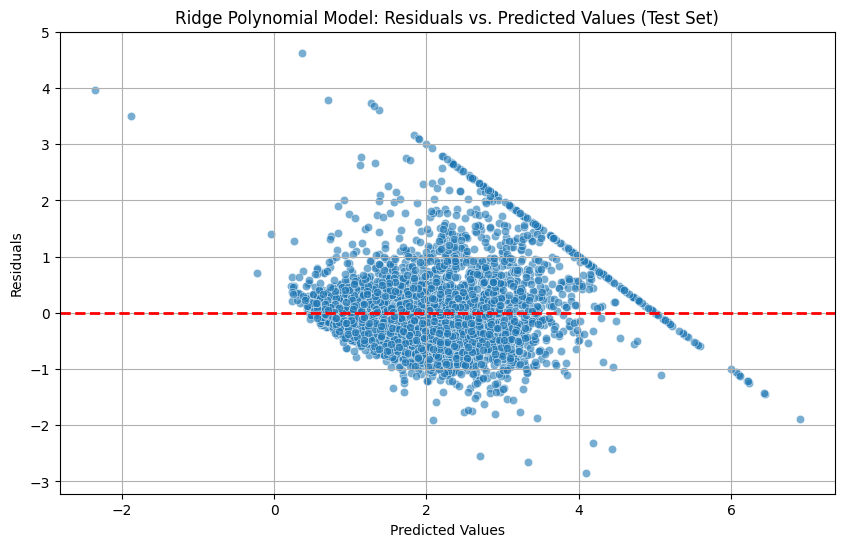

In [105]:
# Calculate residuals
ridge_poly_residuals = y_test - ridge_poly_predictions

# Create a scatter plot of Residuals vs. Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=ridge_poly_predictions, y=ridge_poly_residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero residual line
plt.title('Ridge Polynomial Model: Residuals vs. Predicted Values (Test Set)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

Summary of Findings:

Performance: The Ridge Polynomial Features model currently offers the best test performance among the models evaluated so far, with a Test R2 of 0.657 and a Train R2 of 0.673. This indicates that Ridge regularization successfully mitigated the overfitting observed in the plain Polynomial Features model.
Residual Analysis: While the model generally provides good predictions, the residuals plot revealed signs of heteroscedasticity. Specifically, the spread of residuals increases with higher predicted values, suggesting that the model's predictive accuracy varies across the range of target values, being less reliable for higher-priced homes.